**Task 4: Banking Market Prediction Using Decision Tree Classifier**

The Following Tasks:
1. Data Exploration
2. Data Cleaning
3. Traning The Decision Tree Model
4. Calculating Metrics and Finding The Top Features

**Imporing libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from category_encoders import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

**First: Data Loading and Exploration**

In [4]:
#Loading the dataset and converting it to a DataFrame
df = pd.read_csv('bank-additional-full.csv', sep = ';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [5]:
#Exploring the first 5 rows in the dataset
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
#Exploring the last 5 rows in the dataset
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [7]:
#Exploring the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
#Exploring the shape of the dataset
df.shape

(41188, 21)

In [9]:
#Exploring the values of the first row in the dataset
df.iloc[0]

age                        56
job                 housemaid
marital               married
education            basic.4y
default                    no
housing                    no
loan                       no
contact             telephone
month                     may
day_of_week               mon
duration                  261
campaign                    1
pdays                     999
previous                    0
poutcome          nonexistent
emp.var.rate              1.1
cons.price.idx         93.994
cons.conf.idx           -36.4
euribor3m               4.857
nr.employed            5191.0
y                          no
Name: 0, dtype: object

In [10]:
#Exploring names of columns in the dataset
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [11]:
#Exploring the statistical information in the dataset
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [12]:
#Exploring the index of the dataset
df.index

RangeIndex(start=0, stop=41188, step=1)

In [13]:
#Exploring datatype of each column in the dataset
df_dtypes = pd.DataFrame({'Column': df.columns, 'Data Type': df.dtypes}).reset_index().drop('index', axis = 1)
df_dtypes

,Column,Data Type
0,age,int64
1,job,object
2,marital,object
3,education,object
4,default,object
5,housing,object
6,loan,object
7,contact,object
8,month,object
9,day_of_week,object


In [14]:
#Making the correlation of numerical columns
df_corr = df.select_dtypes(include = 'number').corr()

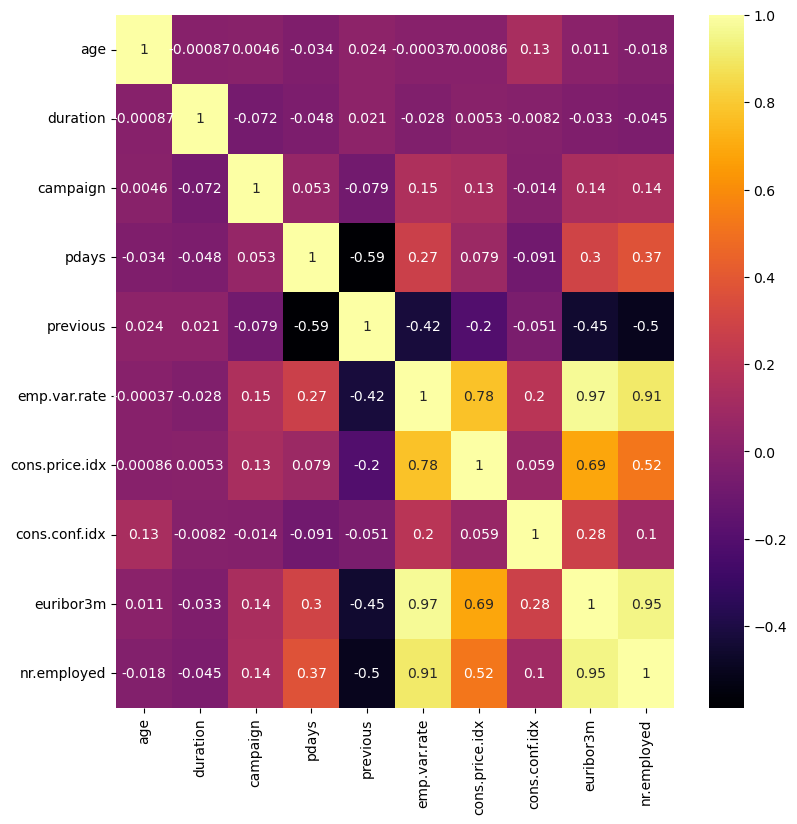

In [16]:
#Plotting a heatmap to this 
fig, ax = plt.subplots(figsize = (9,9))
sns.heatmap(df_corr, annot = True, cmap = 'inferno', ax = ax)
plt.show()

**From this plot:**

We concluded that the column 'euribor3m' has strong positive relationship, one with 'nr.employed' and the 'emp.var.rate' and the columns 'nr.employeed' and 'emp.var.rate' have a strong positive relationship with each other

**Second Part: Data Cleaning**

In [17]:
#First: Renaming some columns
#Define mapping
name_mapping = {'emp.var.rate': 'employment_variation_rate',
    'cons.price.idx': 'consumer_price_index',
    'cons.conf.idx': 'consumer_confidence_index',
    'nr.employed': 'number_employed',
    'y': 'target',
    'poutcome': 'previous_outcome',
    'pdays': 'days_since_previous',
    'euribor3m': 'euribor_3m'}

In [18]:
#Renaming columns 
df = df.rename(columns = name_mapping)
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'days_since_previous',
 'previous',
 'previous_outcome',
 'employment_variation_rate',
 'consumer_price_index',
 'consumer_confidence_index',
 'euribor_3m',
 'number_employed',
 'target']

<Axes: xlabel='duration'>

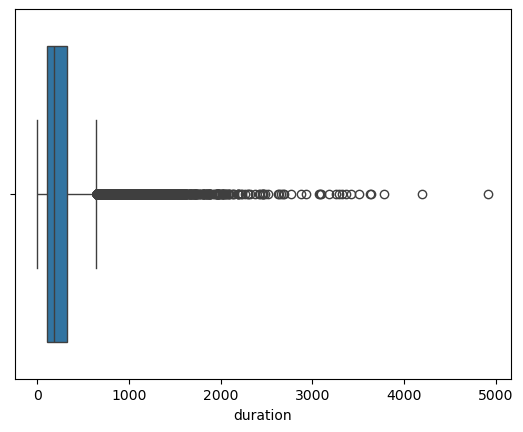

In [19]:
#Second: Detecting outliers
#Exploring outliers of duration
sns.boxplot(data = df, x = 'duration')

In [20]:
#Detecting outliers 
df_detected = df.loc[lambda x: x['duration'].between(x['duration'].quantile(0.10), x['duration'].quantile(0.90))]
print(f'We detected {len(df) - len(df_detected)} rows')

We detected 8154 rows


In [21]:
df = df_detected
df.shape

(33034, 21)

In [23]:
#Exploring duplicates
df.duplicated().sum()

np.int64(10)

In [24]:
#Dropping these duplicates
df = df.drop_duplicates(keep = 'last')

In [26]:
df.shape

(33024, 21)

In [28]:
#Converting the target column to a binary column 
df['target'] = df['target'].map({'yes': 1, 'no': 0})

C:\Users\ibrah\AppData\Local\Temp\ipykernel_7712\3576135640.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df['target'].map({'yes': 1, 'no': 0})


In [29]:
df['target'].unique().tolist()

[0, 1]

In [30]:
#Exploring missing values 
df.isnull().sum()

age                          0
job                          0
marital                      0
education                    0
default                      0
housing                      0
loan                         0
contact                      0
month                        0
day_of_week                  0
duration                     0
campaign                     0
days_since_previous          0
previous                     0
previous_outcome             0
employment_variation_rate    0
consumer_price_index         0
consumer_confidence_index    0
euribor_3m                   0
number_employed              0
target                       0
dtype: int64

In [32]:
#Checking for number of unknown values in each column 
for col in df.select_dtypes(include = 'object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0: 
        print(f"Column: {col} has {unknown_count} unknown values")

Column: job has 265 unknown values
Column: marital has 60 unknown values
Column: education has 1386 unknown values
Column: default has 6840 unknown values
Column: housing has 803 unknown values
Column: loan has 803 unknown values


In [34]:
#Replacing unknown values with NaN
df = df.replace('unknown', np.nan)
df.isnull().sum()

age                             0
job                           265
marital                        60
education                    1386
default                      6840
housing                       803
loan                          803
contact                         0
month                           0
day_of_week                     0
duration                        0
campaign                        0
days_since_previous             0
previous                        0
previous_outcome                0
employment_variation_rate       0
consumer_price_index            0
consumer_confidence_index       0
euribor_3m                      0
number_employed                 0
target                          0
dtype: int64

In [35]:
#Dropping rows that has at leat (np.nan) value
df = df.dropna()

In [36]:
df.shape

(24478, 21)

**Third Part: Training The Decision Tree Model**

In [38]:
#Defining the feature matrix and target vector
#Target Vector
target_vector = 'target'
#Feature Matrix
feature_matrix = [col for col in df.columns if col not in ['target', 'duration']]

#Assigning variables
X = df[feature_matrix]
y = df[target_vector]

In [39]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (24478, 19)
y shape: (24478,)


In [44]:
#Assigning train and test variables using train-test split
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.2, random_state = 42)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_val.shape} ")

Training set: (15665, 19)
Testing set: (3917, 19) 


In [45]:
#Initializing the baseline accuracy 
baseline_acc = y_train.value_counts(normalize = True).max()
majority_class = y_train.value_counts().idxmax()

print(f"Predicting {majority_class} for all observations gives {baseline_acc:.2%} accuracy ")

Predicting 0 for all observations gives 90.23% accuracy 


In [46]:
#Initializing the decision tree model 
model = Pipeline([('encoder', OrdinalEncoder()), ('tree', DecisionTreeClassifier(max_depth = 6, random_state = 42))])

In [47]:
model.fit(X_train, y_train)

,steps,"[('encoder', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,mapping,"[{'col': 'job', 'data_type': dtype('O'), 'mapping': admin. ...2 dtype: int64}, {'col': 'marital', 'data_type': dtype('O'), 'mapping': single 1...2 dtype: int64}, ...]"
,cols,"['job', 'marital', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [49]:
#Calculating train and test accuracy
train_acc = accuracy_score(y_train, model.predict(X_train))
print(f"Train Accuracy: {train_acc:.2f}")
val_acc = accuracy_score(y_val, model.predict(X_val))
print(f"Test Accuracy: {val_acc:.2f}")

Train Accuracy: 0.92
Test Accuracy: 0.91


Both train and test accuracies are high and close to each other and indicates that the model is really well 

In [54]:
#Training the model on many depths and defining the best depth 
depths = range(1, 16)
train_accuracies = []
test_accuracies = []
for i in depths:
    model = Pipeline([('encoder', OrdinalEncoder()), ('tree', DecisionTreeClassifier(max_depth = i, random_state = 42))])
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_val, model.predict(X_val))
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

df_tree = pd.DataFrame({'depth': depths, 'train_accuracy': train_accuracies, 'test_accuracy': test_accuracies}).reset_index().drop('index', axis = 1)
df_tree

,depth,train_accuracy,test_accuracy
0,1,0.902266,0.894562
1,2,0.915991,0.910646
2,3,0.917204,0.910135
3,4,0.918289,0.912178
4,5,0.920715,0.911667
5,6,0.923205,0.908348
6,7,0.926971,0.907838
7,8,0.931823,0.905285
8,9,0.936866,0.906051
9,10,0.942292,0.903242


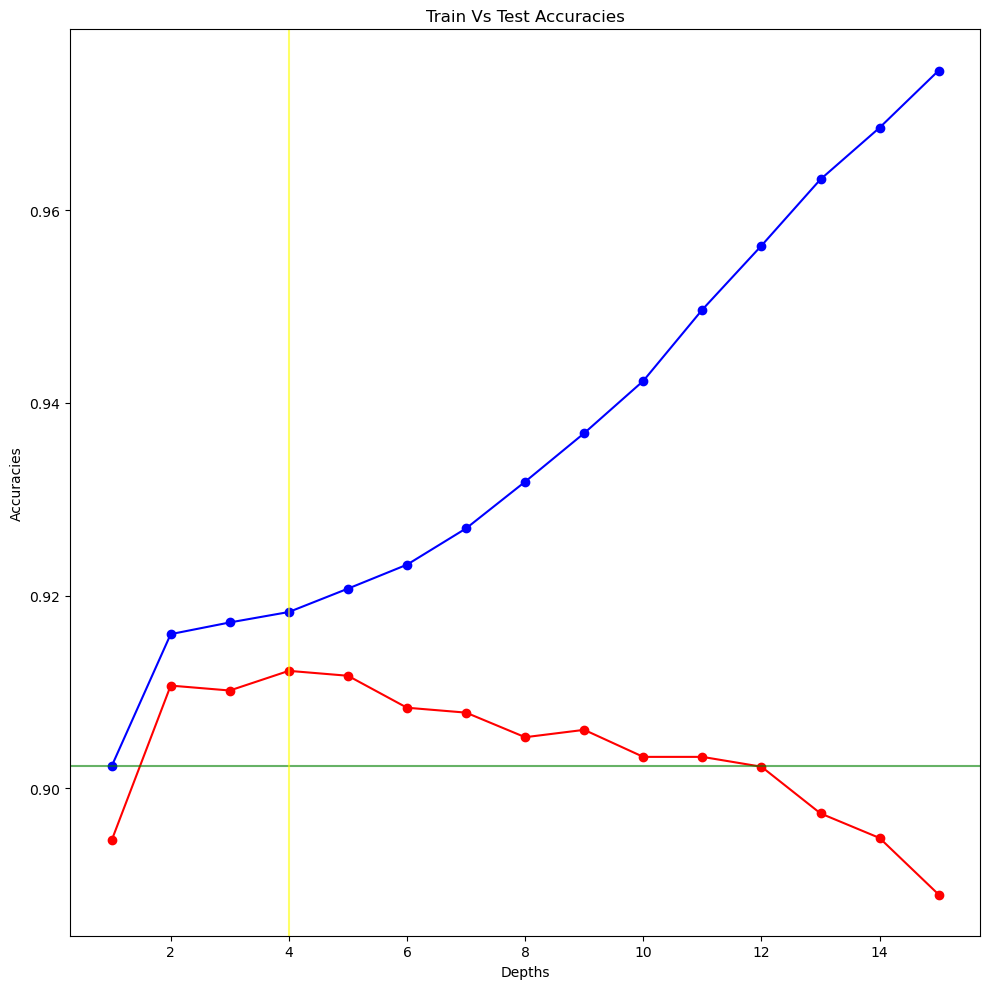

In [56]:
#Visualizing the train and test accuracies
best_depth = list(depths)[test_accuracies.index(max(test_accuracies))]
fig, ax = plt.subplots(figsize = (10,10))
ax.plot(df_tree['depth'], df_tree['train_accuracy'], color = 'blue' ,marker = 'o', label = f'Train Accuracy {df_tree['train_accuracy']}')
ax.plot(df_tree['depth'], df_tree['test_accuracy'], color = 'red' ,marker = 'o', label = f'Train Accuracy {df_tree['test_accuracy']}')
ax.axhline(y = baseline_acc, alpha = 0.6, color = 'green')
ax.axvline(x = best_depth, alpha = 0.6, color = 'yellow')
ax.set_title('Train Vs Test Accuracies')
ax.set_xlabel('Depths')
ax.set_ylabel('Accuracies')
plt.tight_layout()
plt.show()

**From this plot:**

The best depth that if we exceed it, the model will be overfitting is the depth = 4 and this is the optimal depth for this model 

In [58]:
#Initializing the model that has the optimal depth and training this model 
final_model = Pipeline([('encoder', OrdinalEncoder()), ('tree', DecisionTreeClassifier(max_depth = best_depth, random_state = 42))])
final_model.fit(X_train, y_train)

,steps,"[('encoder', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,mapping,"[{'col': 'job', 'data_type': dtype('O'), 'mapping': admin. ...2 dtype: int64}, {'col': 'marital', 'data_type': dtype('O'), 'mapping': single 1...2 dtype: int64}, ...]"
,cols,"['job', 'marital', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [59]:
#Calculating the train and test accuracy for this final model 
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_val, model.predict(X_val))

print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Testing accuracy: {test_accuracy:.2f}")

Training accuracy: 0.97
Testing accuracy: 0.89


In [62]:
#Calculating the precision score for this final model
precision_value = precision_score(y_val, model.predict(X_val))
print(f"Precision Score: {precision_value:.2f}")
print(f"Indicating that the model caught {precision_value:.2%} of the actual scores")

Precision Score: 0.47
Indicating that the model caught 46.86% of the actual scores


In [64]:
#Calcualting the recall score for this final model 
recall_value = recall_score(y_val, model.predict(X_val))
print(f"Recall Score: {recall_value:.2f}")
print(f"Indicating that of the actual scores, the model caught {recall_value:.2%}.")

Recall Score: 0.40
Indicating that of the actual scores, the model caught 39.71%.


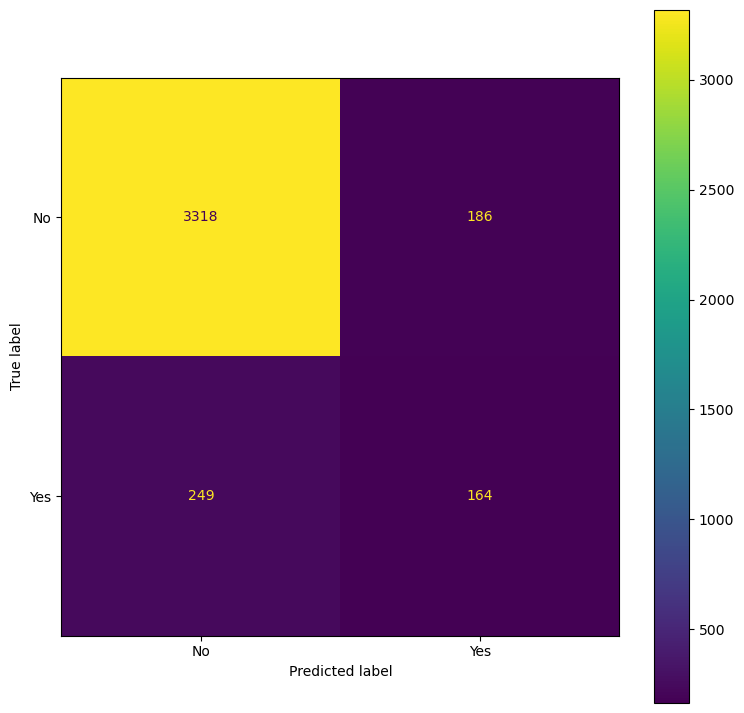

In [65]:
#Confusion matrix creation
cm = confusion_matrix(y_val, model.predict(X_val))
fig, ax = plt.subplots(figsize = (9, 9))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No', 'Yes'])
disp.plot(ax = ax)
plt.show()

**From this plot:**

While the model has high overall accuracy due to the large number of "No" clients, it struggles to accurately identify the "Yes" class (the minority class). It misses more actual subscribers (249) than it successfully catches (164).

In [68]:
#Getting features and coefficients
feature_importances = final_model.named_steps['tree'].feature_importances_
feature_names = final_model.named_steps['encoder'].get_feature_names_out()
df_coef_features = pd.Series(feature_importances, index = feature_names)
df_coef_features

age                          0.000000
job                          0.000000
marital                      0.000000
education                    0.013292
default                      0.000000
housing                      0.000000
loan                         0.000000
contact                      0.000000
month                        0.034668
day_of_week                  0.000000
campaign                     0.006582
days_since_previous          0.007560
previous                     0.000000
previous_outcome             0.113579
employment_variation_rate    0.006326
consumer_price_index         0.009783
consumer_confidence_index    0.121649
euribor_3m                   0.014323
number_employed              0.672238
dtype: float64

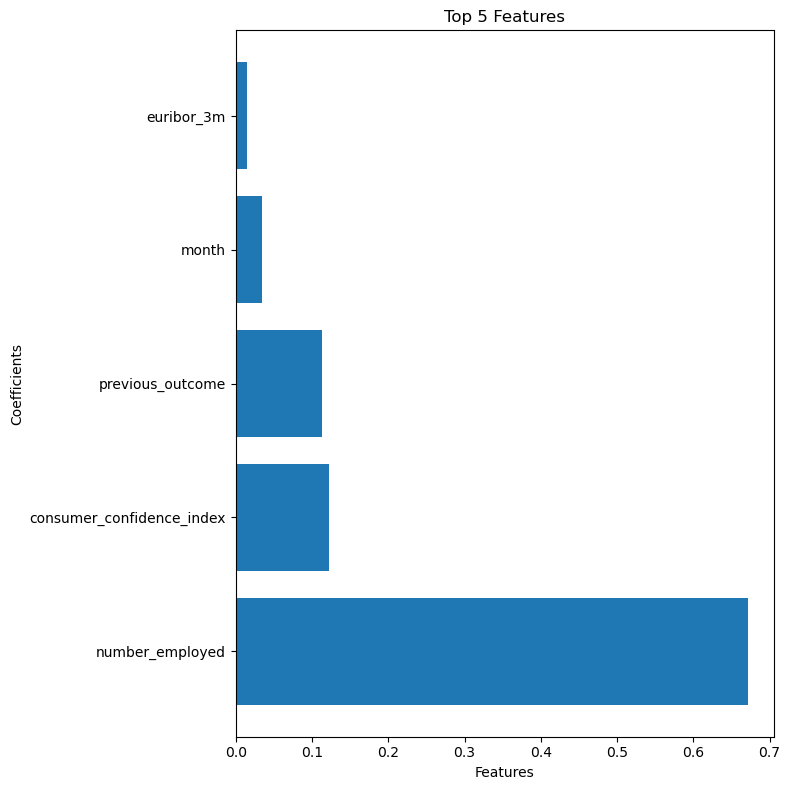

In [69]:
#Plotting the top 5 features
top_5_features = df_coef_features.sort_values(ascending = False).head(5)
fig, ax = plt.subplots(figsize = (8,8))
ax.barh(top_5_features.index, width = top_5_features.values)
ax.set_title('Top 5 Features')
ax.set_xlabel('Features')
ax.set_ylabel('Coefficients')
plt.tight_layout()
plt.show()

**Brief Summary:**

The Decision Tree model achieved high overall accuracy (~89%) but struggled to identify positive term deposit subscriptions due to class imbalance (40% recall). Feature importance analysis reveals that macroeconomic indicators—specifically the number of employees (number_employed) and consumer confidence (consumer_confidence_index)—are the strongest predictors of a client's decision, significantly outweighing personal demographics.